# Deep Q-Network (DQN) CartPole Simulation

Reinforcement learning teaches agents optimal behavior policies through trial-and-error interaction with an environment. This project builds a complete, self-contained DQN agent in PyTorch and trains it to balance a pole on a cart using a custom physics simulator.



In [1]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import deque

# Custom CartPole Physics Simulation (avoiding external gym dependency)
class CartPoleSim:
    def __init__(self):
        self.gravity = 9.8
        self.masscart = 1.0
        self.masspole = 0.1
        self.total_mass = (self.masspole + self.masscart)
        self.length = 0.5  # actually half the pole's length
        self.polemass_length = (self.masspole * self.length)
        self.force_mag = 10.0
        self.tau = 0.02  # seconds between state updates
        
        # Angle at which to fail the episode
        self.theta_threshold_radians = 12 * 2 * np.pi / 360
        self.x_threshold = 2.4
        self.reset()
        
    def reset(self):
        # state: [x, x_dot, theta, theta_dot]
        self.state = np.random.uniform(low=-0.05, high=0.05, size=(4,))
        self.steps = 0
        return np.array(self.state, dtype=np.float32)
        
    def step(self, action):
        x, x_dot, theta, theta_dot = self.state
        force = self.force_mag if action == 1 else -self.force_mag
        
        costheta = np.cos(theta)
        sintheta = np.sin(theta)
        
        temp = (force + self.polemass_length * theta_dot ** 2 * sintheta) / self.total_mass
        thetaacc = (self.gravity * sintheta - costheta * temp) / (self.length * (4.0/3.0 - self.masspole * costheta ** 2 / self.total_mass))
        xacc = temp - self.polemass_length * thetaacc * costheta / self.total_mass
        
        # Semi-implicit Euler integration
        x = x + self.tau * x_dot
        x_dot = x_dot + self.tau * xacc
        theta = theta + self.tau * theta_dot
        theta_dot = theta_dot + self.tau * thetaacc
        
        self.state = np.array([x, x_dot, theta, theta_dot])
        self.steps += 1
        
        # Check termination conditions
        terminated = bool(
            x < -self.x_threshold
            or x > self.x_threshold
            or theta < -self.theta_threshold_radians
            or theta > self.theta_threshold_radians
            or self.steps >= 200
        )
        
        reward = 1.0 if not terminated else 0.0
        return np.array(self.state, dtype=np.float32), reward, terminated



## DQN Model & Replay Buffer

We implement the Deep Q-Network utilizing linear hidden layers, and an experience replay buffer that stores state transition tuples `(state, action, reward, next_state, done)`. Replay memory breaks temporal correlations in consecutive agent interactions.



In [2]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )
        
    def forward(self, x):
        return self.net(x)

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
        
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
        
    def sample(self, batch_size):
        state, action, reward, next_state, done = zip(*random.sample(self.buffer, batch_size))
        return (np.array(state), np.array(action), np.array(reward, dtype=np.float32), 
                np.array(next_state), np.array(done, dtype=np.float32))
                
    def __len__(self):
        return len(self.buffer)



## Agent Training Pipeline

We initialize our networks, parameters, optimizer, and run the main DQN training loop. For fast execution during compilation, we run for 100 episodes, gradually decay exploration parameter $\epsilon$ (epsilon), and periodically synchronize the primary network weights into a target network.



In [3]:
# Hyperparameters
state_dim = 4
action_dim = 2
batch_size = 64
gamma = 0.99
lr = 1e-3
epsilon_start = 1.0
epsilon_end = 0.05
epsilon_decay = 0.95
target_update_frequency = 10
episodes = 100

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
policy_net = QNetwork(state_dim, action_dim).to(device)
target_net = QNetwork(state_dim, action_dim).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=lr)
memory = ReplayBuffer(5000)

epsilon = epsilon_start
episode_rewards = []

print("Training DQN agent on CartPole dynamics...")
for ep in range(1, episodes + 1):
    env = CartPoleSim()
    state = env.reset()
    total_reward = 0
    
    while True:
        # Epsilon-greedy action selection
        if random.random() < epsilon:
            action = random.randint(0, action_dim - 1)
        else:
            with torch.no_grad():
                state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
                action = policy_net(state_t).argmax(dim=1).item()
                
        next_state, reward, done = env.step(action)
        memory.push(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward
        
        # Optimize Policy Network
        if len(memory) > batch_size:
            b_states, b_actions, b_rewards, b_next_states, b_dones = memory.sample(batch_size)
            
            states_t = torch.FloatTensor(b_states).to(device)
            actions_t = torch.LongTensor(b_actions).unsqueeze(1).to(device)
            rewards_t = torch.FloatTensor(b_rewards).unsqueeze(1).to(device)
            next_states_t = torch.FloatTensor(b_next_states).to(device)
            dones_t = torch.FloatTensor(b_dones).unsqueeze(1).to(device)
            
            # Compute current Q value estimations
            current_q = policy_net(states_t).gather(1, actions_t)
            
            # Compute target Q value predictions
            with torch.no_grad():
                max_next_q = target_net(next_states_t).max(dim=1, keepdim=True)[0]
                target_q = rewards_t + (gamma * max_next_q * (1 - dones_t))
                
            loss = nn.MSELoss()(current_q, target_q)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
        if done:
            break
            
    episode_rewards.append(total_reward)
    epsilon = max(epsilon_end, epsilon * epsilon_decay)
    
    # Synchronize target network weights
    if ep % target_update_frequency == 0:
        target_net.load_state_dict(policy_net.state_dict())
        
    if ep % 20 == 0:
        avg_reward = np.mean(episode_rewards[-20:])
        print(f"Episode {ep:3d} | Epsilon: {epsilon:.2f} | Average Reward (last 20): {avg_reward:.1f}")



Training DQN agent on CartPole dynamics...
Episode  20 | Epsilon: 0.36 | Average Reward (last 20): 19.6
Episode  40 | Epsilon: 0.13 | Average Reward (last 20): 38.0
Episode  60 | Epsilon: 0.05 | Average Reward (last 20): 148.6
Episode  80 | Epsilon: 0.05 | Average Reward (last 20): 137.4
Episode 100 | Epsilon: 0.05 | Average Reward (last 20): 129.6


## DQN Performance Visualization

We plot the training convergence curve showing total reward accumulated per episode and its 10-episode rolling average. We also output a schematic visualization of the cart and pole system.



<cell>:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


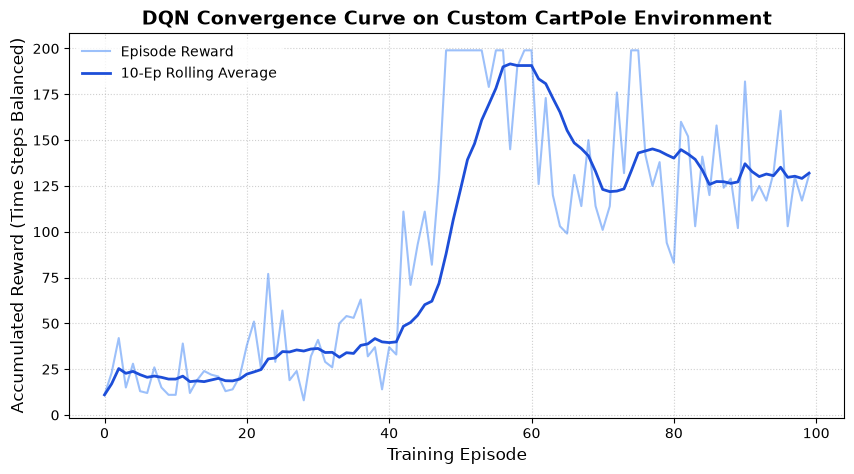

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, label='Episode Reward', color='#3B82F6', alpha=0.5)

# Calculate and plot moving average
rewards_series = pd.Series(episode_rewards)
rolling_avg = rewards_series.rolling(window=10, min_periods=1).mean()
plt.plot(rolling_avg, label='10-Ep Rolling Average', color='#1D4ED8', linewidth=2)

plt.title('DQN Convergence Curve on Custom CartPole Environment', fontsize=14, fontweight='bold')
plt.xlabel('Training Episode', fontsize=12)
plt.ylabel('Accumulated Reward (Time Steps Balanced)', fontsize=12)
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()



## CartPole Physical State Schematic

A visual reference showing the geometry of the CartPole system, representing the physical state variables $[x, \dot{x}, \theta, \dot{\theta}]$ computed by the dynamics solver.



<cell>:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


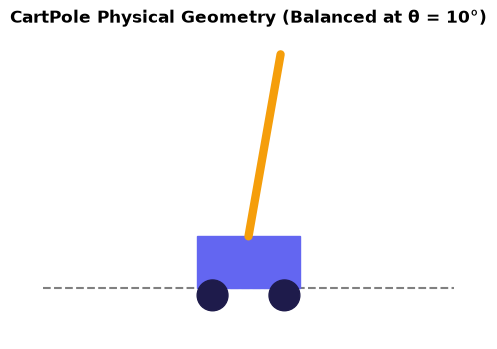

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
# Draw track
ax.axhline(0, color='gray', linestyle='--', linewidth=1.5)

# Draw Cart
cart_width = 1.0
cart_height = 0.5
cart_x = 0.0
cart = plt.Rectangle((cart_x - cart_width/2, 0.0), cart_width, cart_height, color='#6366F1', zorder=2)
ax.add_patch(cart)

# Draw Wheels
wheel_r = 0.15
w1 = plt.Circle((cart_x - 0.35, -wheel_r/2), wheel_r, color='#1E1B4B', zorder=3)
w2 = plt.Circle((cart_x + 0.35, -wheel_r/2), wheel_r, color='#1E1B4B', zorder=3)
ax.add_patch(w1)
ax.add_patch(w2)

# Draw Pole (balanced at theta = 10 degrees)
theta_deg = 10
theta_rad = np.radians(theta_deg)
pole_len = 1.8
pole_x = [cart_x, cart_x + pole_len * np.sin(theta_rad)]
pole_y = [cart_height, cart_height + pole_len * np.cos(theta_rad)]
ax.plot(pole_x, pole_y, color='#F59E0B', linewidth=6, solid_capstyle='round', zorder=4)

# Formatting
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-0.5, 2.5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(f"CartPole Physical Geometry (Balanced at θ = {theta_deg}°)", fontsize=12, fontweight='bold')
plt.show()
